In [1]:
#ML (knn, rfc, svm, gridsearch, random search): Uyên

In [2]:
#KNN - Cat or dog

In [3]:
import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import joblib
from sklearn.model_selection import RandomizedSearchCV


In [4]:
def load_images(folder):
    data = []
    labels = []
    for label_name in ['cat', 'dog']:
        label = 0 if label_name == 'cat' else 1
        folder_path = os.path.join(folder, label_name)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue
            img = cv2.resize(img, (64, 64))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.flatten() / 255.0  
            data.append(img)
            labels.append(label)
    return np.array(data), np.array(labels)

In [5]:
print(os.getcwd())

C:\Users\thuuy\_python\ml


In [6]:
train_dir = r"C:\Users\thuuy\_python\ml\data_folder\train"
test_dir = r"C:\Users\thuuy\_python\ml\data_folder\test"
val_dir = r"C:\Users\thuuy\_python\ml\data_folder\val"


In [7]:
def count_images(folder):
    for label_name in ['cat', 'dog']:
        folder_path = os.path.join(folder, label_name)
        num_images = len(os.listdir(folder_path))
        print(f"{label_name.capitalize()} images in {folder}: {num_images}")

count_images(train_dir)
count_images(val_dir)
count_images(test_dir)

Cat images in C:\Users\thuuy\_python\ml\data_folder\train: 9985
Dog images in C:\Users\thuuy\_python\ml\data_folder\train: 10015
Cat images in C:\Users\thuuy\_python\ml\data_folder\val: 1248
Dog images in C:\Users\thuuy\_python\ml\data_folder\val: 1252
Cat images in C:\Users\thuuy\_python\ml\data_folder\test: 1268
Dog images in C:\Users\thuuy\_python\ml\data_folder\test: 1233


In [8]:
X_train, y_train = load_images(train_dir)
X_val, y_val     = load_images(val_dir)
X_test, y_test   = load_images(test_dir)

In [9]:
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_test_pca  = pca.transform(X_test)

In [10]:
X_search,_, y_search,_ = train_test_split(X_train_pca, y_train, test_size=0.2, stratify=y_train, random_state=42)


In [11]:
param_dist = {
    'n_neighbors': range(1, 100),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=20,           
    cv=3,               
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_search, y_search)

print("\nBest parameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'weights': 'distance', 'n_neighbors': 28, 'metric': 'euclidean'}
Best cross-validation score: 0.6145622079445207


In [12]:
knn_model = random_search.best_estimator_
knn_model.fit(X_train_pca, y_train)

y_val_pred =knn_model.predict(X_val_pca)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

Validation Accuracy: 0.6156


In [13]:
y_test_pred = knn_model.predict(X_test_pca)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Test Accuracy: 0.6404



Classification Report on Test Set:

              precision    recall  f1-score   support

         Cat       0.69      0.53      0.60      1267
         Dog       0.61      0.75      0.67      1233

    accuracy                           0.64      2500
   macro avg       0.65      0.64      0.64      2500
weighted avg       0.65      0.64      0.64      2500

Confusion Matrix:
 [[676 591]
 [308 925]]
Confusion matrix saved to knn_confusion_matrix.png


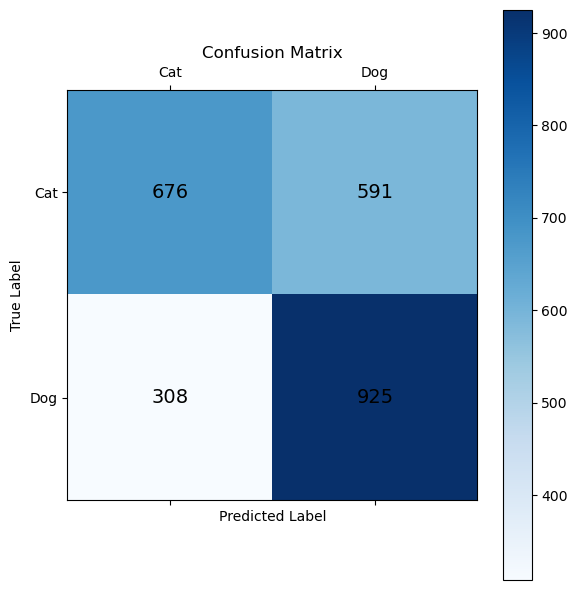

In [14]:
from sklearn.metrics import classification_report
print("\nClassification Report on Test Set:\n")
print(classification_report(y_test, y_test_pred, target_names=['Cat', 'Dog']))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

def plot_confusion_matrix(cm, class_names, save_path='knn_confusion_matrix.png'):
    fig, ax = plt.subplots(figsize=(6,6))
    cax = ax.matshow(cm, cmap='Blues')
    plt.colorbar(cax)
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, str(val), ha='center', va='center', fontsize=14)
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)  
        print(f"Confusion matrix saved to {save_path}")
    plt.show()

plot_confusion_matrix(cm, ['Cat', 'Dog'])


In [15]:
joblib.dump((knn_model, pca), "knn_model.pkl", compress=3)
print("Saved model to knn_model.pkl")

Saved model to knn_model.pkl
